In [4]:
# Packages

import os
os.chdir("C:/Users/lulum/Documents/Syracuse Projects/BRFSS ML Project")

import pandas as pd
import numpy as np

In [5]:
# Data import

brfss = pd.read_stata("Output/BRFSS_Merged.dta")
brfss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336125 entries, 0 to 1336124
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Age_group          1336125 non-null  float64
 1   Sex                1336125 non-null  float64
 2   BMI                1203747 non-null  float64
 3   Obese              1336125 non-null  float64
 4   Height_in_m        1261272 non-null  float64
 5   Physical_Activity  1336125 non-null  float64
 6   Weight_in_kg       1223504 non-null  float64
 7   Smoker             1336125 non-null  float64
 8   Education_level    1336125 non-null  float64
 9   Income_Cat         1336125 non-null  float64
 10  Diabetes           1336113 non-null  float64
 11  Asthma             203097 non-null   float64
 12  Kidney_Disease     1336114 non-null  float64
 13  Arthritis          1328359 non-null  float64
 14  Heavy_Drinker      1336125 non-null  float64
 15  High_Cholesterol   1284313 non-n

# Recoding Variables from Numeric to Categorical Format

In [6]:

# Mapping Values In Categorical Variables ... Changing them From Numeric to Categories

# INCOME

# Converting  income var to integer
brfss["Income_Cat"] = brfss["Income_Cat"].astype("Int64")

# Ordered income categories
income_order = [
        "Less than $15,000",
        "$15,000 < $25,000",
        "$25,000 < $35,000",
        "$35,000 < $50,000",
        "$50,000 < $100,000",
        "$100,000 < $200,000",
        "$200,000 or more",
        "Missing/Don’t know",
]

# Replacing numeric codes with categories 
brfss["Income_Cat"] = pd.Categorical(
    brfss["Income_Cat"].map({
        1: "Less than $15,000",
        2: "$15,000 < $25,000",
        3: "$25,000 < $35,000",
        4: "$35,000 < $50,000",
        5: "$50,000 < $100,000",
        6: "$100,000 < $200,000",
        7: "$200,000 or more",
        9: np.nan
    }),
    categories = income_order,
    ordered = True
)

# EDUCATION

# Converting  education variable to integer 
brfss["Education_level"] = brfss["Education_level"].astype("Int64")

# Ordered education categories
education_order = [
    "Did not graduate High School",
    "Graduated High School",
    "Attended College or Technical School",
    "Graduated from College or Technical School",
    "Don’t know/Not sure/Missing"
]

# Replace numeric codes with categories and create an ordered categorical
brfss["Education_level"] = pd.Categorical(
    brfss["Education_level"].map({
        1: "Did not graduate High School",
        2: "Graduated High School",
        3: "Attended College or Technical School",
        4: "Graduated from College or Technical School",
        9: np.nan
    }),
    categories=education_order,
    ordered=True
)

# ALCOHOL

# Converting the column to integer
brfss["Heavy_Drinker"] = brfss["Heavy_Drinker"].astype("Int64")

# Map numeric codes 
brfss["Heavy_Drinker"] = pd.Categorical(
    brfss["Heavy_Drinker"].map({
        1: "No",
        2: "Yes",
        9: np.nan
    })
)

# SMOKING 

# Converting  column to integer 
brfss["Smoker"] = brfss["Smoker"].astype("Int64")

# Map numeric codes to categor
brfss["Smoker"] = pd.Categorical(
    brfss["Smoker"].map({
        1: "No",
        2: "Yes",
        9: np.nan 
    })
)

# OBESE

# Converting column to integer 
brfss["Obese"] = brfss["Obese"].astype("Int64")

# Mapping numeric codes to categories
brfss["Obese"] = brfss["Obese"].map({
    1: "No",
    2: "Yes",
    9: np.nan 
})

# SEX

# Converting to integer 
brfss["Sex"] = brfss["Sex"].astype("Int64")

# Mapping numeric codes to categories
brfss["Sex"] = brfss["Sex"].map({
    1: "Male",
    2: "Female"
})

# AGE GROUP

# Converting column to integer 
brfss["Age_group"] = brfss["Age_group"].astype("Int64")

# Defining the ordered categories
age_order = [
    "Age 18 to 24",
    "Age 25 to 34",
    "Age 35 to 44",
    "Age 45 to 54",
    "Age 55 to 64",
    "Age 65 or older"
]

# Map numeric codes to categories 
brfss["Age_group"] = pd.Categorical(
    brfss["Age_group"].map({
        1: "Age 18 to 24",
        2: "Age 25 to 34",
        3: "Age 35 to 44",
        4: "Age 45 to 54",
        5: "Age 55 to 64",
        6: "Age 65 or older"
    }),
    categories=age_order,
    ordered=True
)

# PHYSICAL ACTIVITY

# Converting column to integer 
brfss["Physical_Activity"] = brfss["Physical_Activity"].astype("Int64")

brfss["Physical_Activity"] = pd.Categorical(
    brfss["Physical_Activity"].map({
        1: "Had physical activity or exercise",
        2: "No physical activity or exercise in last 30 days",
        9: np.nan
    })
)

# ASTHMA

brfss["Asthma"] = pd.Categorical(
    brfss["Asthma"].map({
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan
    })
)

# DIABETES

brfss["Diabetes"] = pd.Categorical(
    brfss["Diabetes"].map({
        1: "Yes",
        2: "No",
        3: "No",
        4: "No",
        7: np.nan,
        9: np.nan
    })
)

# KIDNEY DISEASE

brfss["Kidney_Disease"] = pd.Categorical(
    brfss["Kidney_Disease"].map({
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan
    })
)

# ARTHRITIS

brfss["Arthritis"] = pd.Categorical(
    brfss["Arthritis"].map({
        1: "Yes",
        2: "No"
    })
)

# HIGH CHOLESTEROL

brfss["High_Cholesterol"] = pd.Categorical(
    brfss["High_Cholesterol"].map({
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan,
        999: np.nan  # Years where the variable wasn't captured (2022,2024)
    })
)


# HYPERTENSION

brfss["High_BP"] = pd.Categorical(
    brfss["High_BP"].map({
        1: "Yes",
        2: "No",
        7: np.nan,
        9: np.nan,
        999: np.nan  # Years where the variable wasn't captured (2022,2024)
    })
)


# Summary statistics and distributions  

In [7]:
brfss.describe(include = "category")

,Age_group,Physical_Activity,Smoker,Education_level,Income_Cat,Diabetes,Asthma,Kidney_Disease,Arthritis,Heavy_Drinker,High_Cholesterol,High_BP
count,1336125,1332466,1245579,1329054,1066032,1333020,196993,1330328,1328359,1206897,378239,175720
unique,6,2,2,4,7,2,2,2,2,2,2,2
top,Age 65 or older,Had physical activity or exercise,No,Graduated from College or Technical School,"$50,000 < $100,000",No,Yes,No,No,No,No,Yes
freq,499232,1012847,1103398,563912,327020,1146267,139302,1265706,876128,1132714,219333,144089


# Correlation (Heatmap) for numeric variables

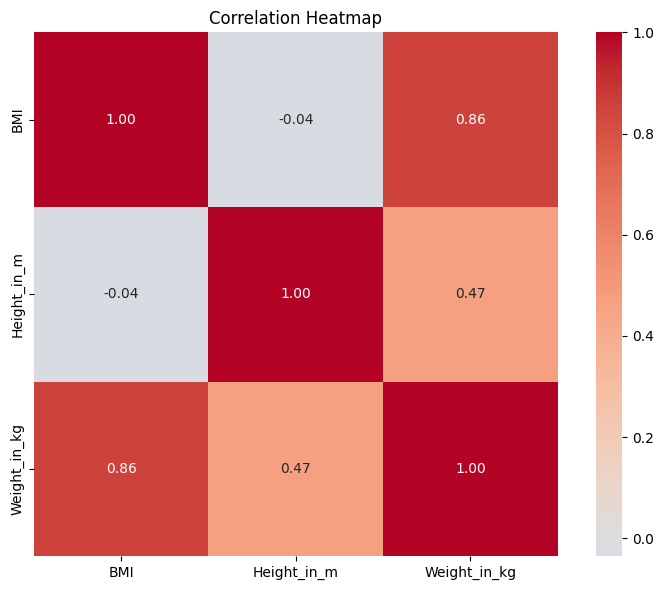

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

num_vars = brfss[['BMI', 'Height_in_m', 'Weight_in_kg']]

cor_matrix = num_vars.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Findings and Conclusion

The correlation analysis revealed a strong positive correlation between BMI and Weight (r = 0.85), indicating the presence of multicollinearity. Since BMI is mathematically derived from both height and weight, retaining all three variables simultaneously would introduce redundant information that could distort model estimates and inflate standard errors. Therefore, Height and Weight were excluded from the model, retaining only BMI as the anthropometric predictor, as it provides a clinically meaningful and non-redundant summary of both measures

In [9]:
# Dropping Leakage Vars 

leakage_cols = ["Height_in_m", "Weight_in_kg"]
brfss = brfss.drop(columns= leakage_cols)
brfss.head()

,Age_group,Sex,BMI,Obese,Physical_Activity,Smoker,Education_level,Income_Cat,Diabetes,Asthma,Kidney_Disease,Arthritis,Heavy_Drinker,High_Cholesterol,High_BP
0,Age 65 or older,Female,NaN,NaN,No physical activity or exercise in last 30 days,No,Graduated from College or Technical School,NaN,Yes,NaN,No,No,No,NaN,NaN
1,Age 65 or older,Female,2657.0,Yes,No physical activity or exercise in last 30 days,No,Graduated High School,"$25,000 < $35,000",No,NaN,No,No,No,NaN,NaN
2,Age 55 to 64,Female,2561.0,Yes,Had physical activity or exercise,No,Graduated from College or Technical School,"$100,000 < $200,000",No,NaN,No,No,No,NaN,NaN
3,Age 65 or older,Female,2330.0,No,Had physical activity or exercise,Yes,Graduated High School,NaN,No,Yes,No,Yes,No,NaN,NaN
4,Age 35 to 44,Female,2177.0,No,Had physical activity or exercise,No,Attended College or Technical School,"$25,000 < $35,000",No,NaN,No,No,No,NaN,NaN


# Data Preprocessing and Feature Engineering

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder
    

#  Ordinal 
ordinal_cols = ["Age_group", "Education_level", "Income_Cat"]
ordinal_orders = [
    ["Age 18 to 24", "Age 25 to 34", "Age 35 to 44",
     "Age 45 to 54", "Age 55 to 64", "Age 65 or older"],
    ["Did not graduate High School", "Graduated High School",
     "Attended College or Technical School",
     "Graduated from College or Technical School",
     "Don't know/Not sure/Missing"],
    ["Less than $15,000", "$15,000 < $25,000", "$25,000 < $35,000",
     "$35,000 < $50,000", "$50,000 < $100,000",
     "$100,000 < $200,000", "$200,000 or more", "Missing/Don't know"],
]

# Ordinal pipeline with mean imputation 
ordinal_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
                   categories=ordinal_orders,
                   handle_unknown="use_encoded_value",
                   unknown_value=np.nan
               )),
])


#  Binary 
binary_cols = ["Sex", "Smoker", "Heavy_Drinker", "Physical_Activity","Diabetes", "Asthma","Kidney_Disease","Arthritis", "High_Cholesterol", "High_BP" ]

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('encoder', OrdinalEncoder())                         
])

# Numeric
numeric_cols = ["BMI"]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   
    ('scaler', StandardScaler())                   
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
    ('ordinal',  ordinal_pipeline,  ordinal_cols),
    ('binary',   binary_pipeline,   binary_cols),
    ('numeric',  numeric_pipeline,  numeric_cols),
], remainder='drop')

#  Fit & Transform
X = brfss[ordinal_cols + binary_cols + numeric_cols]
y = brfss['Obese']


X_processed = preprocessor.fit_transform(X)

# Converting Back to a Dataframe
feature_names = ordinal_cols + binary_cols + numeric_cols
X_processed_data = pd.DataFrame(X_processed, columns=feature_names)

# dropping Missing values in the target variable , 43037 out of 457669 observations
mask = y.notna()
y = y[mask]

# Encoding Y
le = LabelEncoder()
y = le.fit_transform(y)

X_processed_data = X_processed_data[mask]

In [11]:
# Summary stats
print("Shape:", X_processed_data.shape)
print("\nMissing values:\n", X_processed_data.isnull().sum())
print("\nSample:\n", X_processed_data.head())

Shape: (1203747, 14)

Missing values:
 Age_group            0
Education_level      0
Income_Cat           0
Sex                  0
Smoker               0
Heavy_Drinker        0
Physical_Activity    0
Diabetes             0
Asthma               0
Kidney_Disease       0
Arthritis            0
High_Cholesterol     0
High_BP              0
BMI                  0
dtype: int64

Sample:
    Age_group  Education_level  Income_Cat  Sex  Smoker  Heavy_Drinker  \
1        5.0              1.0         2.0  0.0     0.0            0.0   
2        4.0              3.0         5.0  0.0     0.0            0.0   
3        5.0              1.0         4.0  0.0     1.0            0.0   
4        2.0              2.0         2.0  0.0     0.0            0.0   
5        5.0              1.0         4.0  1.0     0.0            0.0   

   Physical_Activity  Diabetes  Asthma  Kidney_Disease  Arthritis  \
1                1.0       0.0     1.0             0.0        0.0   
2                0.0       0.0     1.0 

# Modelling

In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

def run_classifier(classifier):
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed_data, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Applying SMOTE since the target variable is imbalanced
    pipeline = Pipeline([
        ("smote",      SMOTE(random_state=42)),
        ("classifier", classifier)
    ])

    # 5-fold CV
    cv_scores = cross_val_score(pipeline, X_train, y_train, scoring="f1_macro", cv=5)
    print(f"\n{classifier.__class__.__name__}")
    print(f"CV F1 scores : {cv_scores.round(4)}")
    print(f"Mean F1      : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # Model Evaluation
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"\n{classification_report(y_test, y_pred, target_names=['Not Obese', 'Obese'])}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    return cv_scores

In [ ]:
#  Random Forest
run_classifier(RandomForestClassifier(n_estimators=100, random_state=42))

# Training Without BMI

In [ ]:
# BMI is dropped due to data leakage (0.65 correlation with target)
# It directly defines obesity clinically (BMI >= 30 = obese)

X_processed_no_bmi = X_processed_data.drop(columns=["BMI"])
X_processed_data = X_processed_no_bmi

# Retraining without BMI
run_classifier(LogisticRegression(max_iter=1000, random_state=42))
run_classifier(RandomForestClassifier(n_estimators=100, random_state=42))


LogisticRegression
CV F1 scores : [0.5498 0.5488 0.5518 0.5484 0.5497]
Mean F1      : 0.5497 (+/- 0.0012)

              precision    recall  f1-score   support

   Not Obese       0.38      0.68      0.49     75090
       Obese       0.78      0.50      0.61    165660

    accuracy                           0.56    240750
   macro avg       0.58      0.59      0.55    240750
weighted avg       0.65      0.56      0.57    240750

ROC-AUC: 0.6274

RandomForestClassifier
CV F1 scores : [0.5967 0.5966 0.597  0.5975 0.5964]
Mean F1      : 0.5968 (+/- 0.0004)

              precision    recall  f1-score   support

   Not Obese       0.42      0.62      0.50     75090
       Obese       0.78      0.62      0.69    165660

    accuracy                           0.62    240750
   macro avg       0.60      0.62      0.60    240750
weighted avg       0.67      0.62      0.63    240750

ROC-AUC: 0.6587


array([0.59671374, 0.59662763, 0.59695029, 0.59748668, 0.59635443])

In [ ]:
# BMI is dropped due to data leakage (0.65 correlation with target)
# It directly defines obesity clinically (BMI >= 30 = obese)

X_processed_no_bmi = X_processed_data.drop(columns=["BMI"])
X_processed_data = X_processed_no_bmi


from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

run_classifier(xgb_model)


XGBClassifier
CV F1 scores : [0.6026 0.6032 0.6031 0.6023 0.6023]
Mean F1      : 0.6027 (+/- 0.0004)

              precision    recall  f1-score   support

   Not Obese       0.43      0.62      0.51     75090
       Obese       0.78      0.62      0.69    165660

    accuracy                           0.62    240750
   macro avg       0.61      0.62      0.60    240750
weighted avg       0.67      0.62      0.63    240750

ROC-AUC: 0.6697


array([0.60260731, 0.60315089, 0.60310589, 0.60234982, 0.60234332])